# Fish Farming / Model Training / Trainer

# Installing libraries

---



In [ ]:
!pip install albumentations[cuda]               # or albumentations for CPU
!pip install albumentations[pytorch]
!pip install albumentations[imgaug]
!pip install segmentation-models-pytorch

In [2]:
# Install and Import Dependencies
import os, random
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp


# Variables Configuration

---



In [15]:
# Configuration variable to choose between 1-channel and 3-channel processing
num_input_channels = 3 # Set to  3 for 3-channel (e.g., rgb) or 1 for 1-channel (e.g., mndwi)

channel = "rgb" #posible values: rgb, ndwi-mndwi-swir2 ,pi ,ndwi-mndwi-pi ,mndwi
image_dir = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/model_training/data/dataset/"+channel+"/train/images"
mask_dir = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/model_training/data/dataset/"+channel+"/train/masks"
image_dir_val = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/model_training/data/dataset/"+channel+"/val/images"
mask_dir_val = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/model_training/data/dataset/"+channel+"/val/masks"

# Directory to save the model
base_dir = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/model_training/models/"

image_dir_test = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/model_training/data/dataset/"+channel+"/test/images"
mask_dir_test = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/model_training/data/dataset/"+channel+"/test/masks"


# Model Training





## Reading and Preparing dataset

---



In [4]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ----------------------------------------------------------------
# 1) Dataset
# ----------------------------------------------------------------

PATCH_SIZE = 128

class SegmentationDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None, num_input_channels=3):
        self.imgs = img_paths
        self.msks = mask_paths
        self.tf   = transform
        self.num_input_channels = num_input_channels

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # Ensure image data is float32
        if self.num_input_channels == 1:
            im = np.load(self.imgs[idx]).astype(np.float32)             # H×W, cast to float32
            im = np.expand_dims(im, axis=-1) # Add channel dimension H×W×1
        else: # 3 channels
            im = np.load(self.imgs[idx]).astype(np.float32)             # H×W×3, cast to float32

        m  = np.array(Image.open(self.msks[idx]).convert("L"))
        m  = (m >= PATCH_SIZE).astype(np.uint8)                           # H×W

        if self.tf:
            aug = self.tf(image=im, mask=m)
            im, m = aug["image"], aug["mask"]

        if self.num_input_channels == 1:
             return im, m.unsqueeze(0).float()                         # [1×H×W], [1×H×W]
        else:
             return im, m.unsqueeze(0).float()                         # [3×H×W], [1×H×W]


# ----------------------------------------------------------------
# 2) Collect paths
# ----------------------------------------------------------------
train_imgs = sorted(
    os.path.join(image_dir, f)
    for f in os.listdir(image_dir)
    if f.endswith(".npy")
)
train_msks = sorted(
    os.path.join(mask_dir, f)
    for f in os.listdir(mask_dir)
    if f.endswith(".png")
)

# Keep only non-empty masks
train_imgs_filtered, train_msks_filtered = [], []
for im_p, m_p in zip(train_imgs, train_msks):
    pos = (np.array(Image.open(m_p).convert("L")) >= PATCH_SIZE).sum()
    if pos > 0:
        train_imgs_filtered.append(im_p)
        train_msks_filtered.append(m_p)

# ---------------------------
# Val paths
# ---------------------------
val_imgs = sorted(
    os.path.join(image_dir_val, f)
    for f in os.listdir(image_dir_val)
    if f.endswith(".npy")
)
val_msks = sorted(
    os.path.join(mask_dir_val, f)
    for f in os.listdir(mask_dir_val)
    if f.endswith(".png")
)

# Keep only non-empty masks for val set too
val_imgs_filtered, val_msks_filtered = [], []
for im_p, m_p in zip(val_imgs, val_msks):
    pos = (np.array(Image.open(m_p).convert("L")) >= PATCH_SIZE).sum()
    if pos > 0:
        val_imgs_filtered.append(im_p)
        val_msks_filtered.append(m_p)


# Update normalization based on num_input_channels
if num_input_channels == 1:
    IMG_MEAN = (0.5,)  # Example mean for 1-channel data
    IMG_STD  = (0.5,)  # Example std for 1-channel data
else:
    IMG_MEAN = (0.485, 0.456, 0.406)
    IMG_STD  = (0.229, 0.224, 0.225)


# ----------------------------------------------------------------
# 3) Final transforms with computed stats
# ----------------------------------------------------------------

train_tf = A.Compose([
    A.CropNonEmptyMaskIfExists(PATCH_SIZE, PATCH_SIZE, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2()
])
val_tf = A.Compose([
    A.CropNonEmptyMaskIfExists(PATCH_SIZE, PATCH_SIZE, p=1.0),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2()
])

# ----------------------------------------------------------------
# 4) Final datasets & dataloaders
# ----------------------------------------------------------------
train_ds = SegmentationDataset(train_imgs_filtered, train_msks_filtered, transform=train_tf, num_input_channels=num_input_channels)
val_ds   = SegmentationDataset(val_imgs_filtered, val_msks_filtered,   transform=val_tf, num_input_channels=num_input_channels)

# Weighted sampler based on positive pixel count
pos_counts = np.array([
    (np.array(Image.open(m).convert("L")) > 127).sum()
    for m in train_msks
], dtype=np.float32)
weights = pos_counts / pos_counts.sum()
train_sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=4, sampler=train_sampler, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=4, shuffle=False, num_workers=2, pin_memory=True
)

## Device definition


---



In [5]:
# Check Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Model Definition


---



In [6]:
# ----------------------------------------------------------------
# 5) Model, Losses, Optimizer, Scheduler
# ----------------------------------------------------------------

EPOCHS = 100
encoder = "resnet34" ##resnet34
pretrained_data = "imagenet" ##imagenet

model = smp.Unet(
    encoder_name  =encoder,
    encoder_weights=pretrained_data if num_input_channels == 3 else None, # Set weights to None for 1 channel
    in_channels   =num_input_channels, # Use the configuration variable here
    classes       =1,
).to(device)


bce = nn.BCEWithLogitsLoss()
def soft_dice(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num   = 2*(probs*targets).sum(dim=(1,2,3)) + eps
    den   =   probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) + eps
    return (1 - num/den).mean()

opt = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=1e-3, total_steps=EPOCHS*len(train_loader)
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

## Metrics definition

---



In [7]:
# ----------------------------------------------------------------
# 5) Metrics
# ----------------------------------------------------------------
def compute_iou_and_dice(logits, targets, thr=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    intersection = (preds * targets).sum(dim=(1,2,3))
    union        = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) - intersection
    dice_num     = 2*intersection + eps
    dice_den     = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) + eps
    iou  = (intersection + eps) / (union + eps)
    dice = dice_num / dice_den
    return iou.mean().item(), dice.mean().item()

best_val_iou = 0.0

## Visualization functions used during training

---



In [12]:
#-------------------
# For printing images during training
#---------------------
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

def show_image_mask_prediction(image, mask, prediction, threshold=0.5, num_input_channels=3):
    # Reverse normalization for visualization
    if num_input_channels == 1:
        mean = torch.tensor(IMG_MEAN).view(1, 1, 1) # Assuming IMG_MEAN is a tuple like (0.5,)
        std = torch.tensor(IMG_STD).view(1, 1, 1)   # Assuming IMG_STD is a tuple like (0.5,)
        image = image.squeeze(0).cpu() * std + mean # Remove batch dim, then denormalize
        image = image.numpy().transpose(1, 2, 0) # (H, W, 1)
        # For 1-channel, display as grayscale
        image = image.squeeze(-1) # Remove the channel dimension for grayscale display
    else: # 3 channels
        mean = torch.tensor(IMG_MEAN).view(3, 1, 1) # Assuming IMG_MEAN is a tuple like (0.485, 0.456, 0.406)
        std = torch.tensor(IMG_STD).view(3, 1, 1)   # Assuming IMG_STD is a tuple like (0.229, 0.224, 0.225)
        image = image.squeeze(0).cpu() * std + mean # Remove batch dim, then denormalize
        image = image.permute(1, 2, 0).numpy() # (H, W, 3)


    # Ensure mask and prediction are grayscale (H, W) for display
    mask = mask.squeeze().cpu().numpy()
    pred = prediction.squeeze().cpu().numpy()


    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    # Display image based on channels
    if num_input_channels == 1:
        axs[0].imshow(image, cmap='gray')
    else:
        axs[0].imshow(image.clip(0, 1)) # Clip for display

    axs[0].set_title("Input Image")
    axs[1].imshow(mask, cmap='gray')
    axs[1].set_title("Ground Truth Mask")
    axs[2].imshow(pred, cmap='gray')
    axs[2].set_title("Predicted Mask")
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 🦾 Trainig

---



Epoch 01  Train Loss 1.1412  Val Loss 1.1512  Val IoU 0.2043  Val Dice 0.3134 Patience Counter 0 
Epoch 02  Train Loss 1.0795  Val Loss 1.0358  Val IoU 0.2403  Val Dice 0.3581 Patience Counter 0 
Epoch 03  Train Loss 1.0290  Val Loss 0.9224  Val IoU 0.3035  Val Dice 0.4388 Patience Counter 0 
Epoch 04  Train Loss 1.0080  Val Loss 0.8519  Val IoU 0.3909  Val Dice 0.5385 Patience Counter 0 
Epoch 05  Train Loss 0.9789  Val Loss 0.8084  Val IoU 0.4639  Val Dice 0.6253 Patience Counter 0 
Epoch 06  Train Loss 0.9404  Val Loss 0.7630  Val IoU 0.5125  Val Dice 0.6560 Patience Counter 0 
Epoch 07  Train Loss 0.9355  Val Loss 0.7333  Val IoU 0.5245  Val Dice 0.6527 Patience Counter 0 
Epoch 08  Train Loss 0.9264  Val Loss 0.6741  Val IoU 0.5580  Val Dice 0.7073 Patience Counter 0 
Epoch 09  Train Loss 0.8916  Val Loss 0.6431  Val IoU 0.5840  Val Dice 0.7261 Patience Counter 0 
Epoch 10  Train Loss 0.9152  Val Loss 0.6096  Val IoU 0.6253  Val Dice 0.7603 Patience Counter 0 
Epoch 11  Train Loss

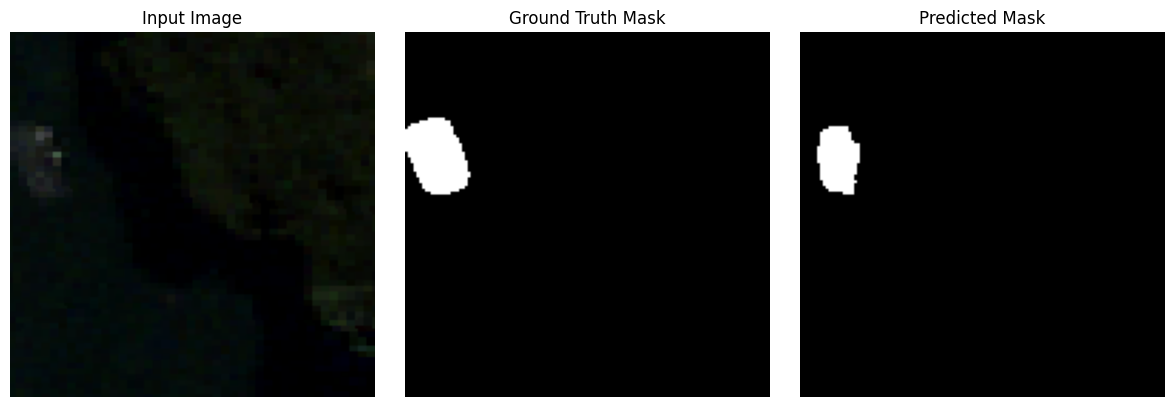

Epoch 20


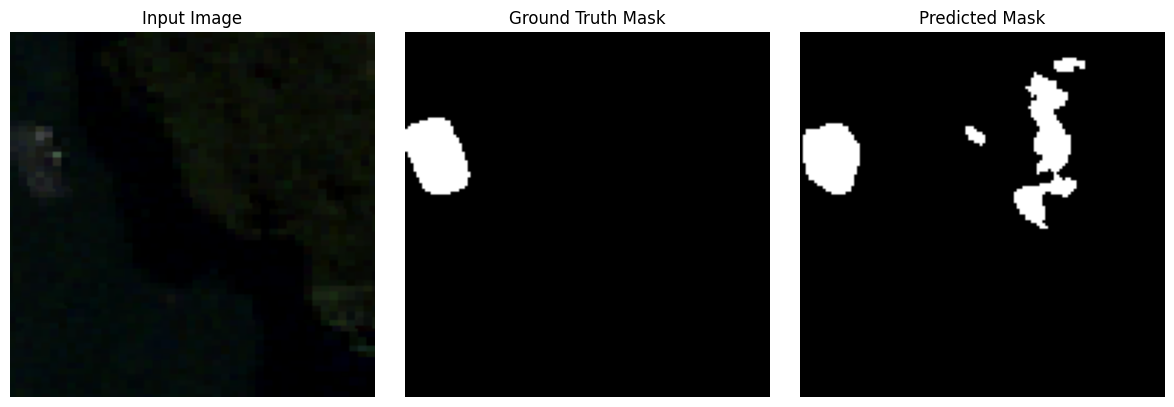

Epoch 30


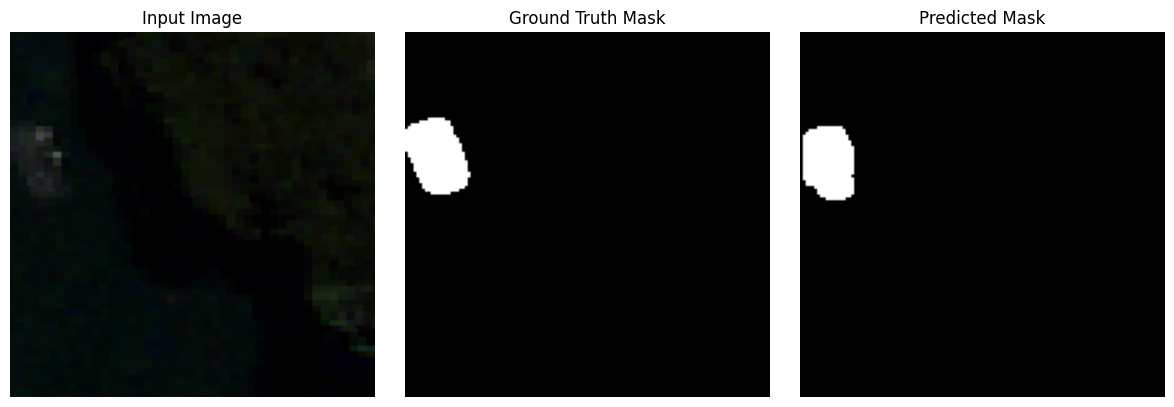

Epoch 40


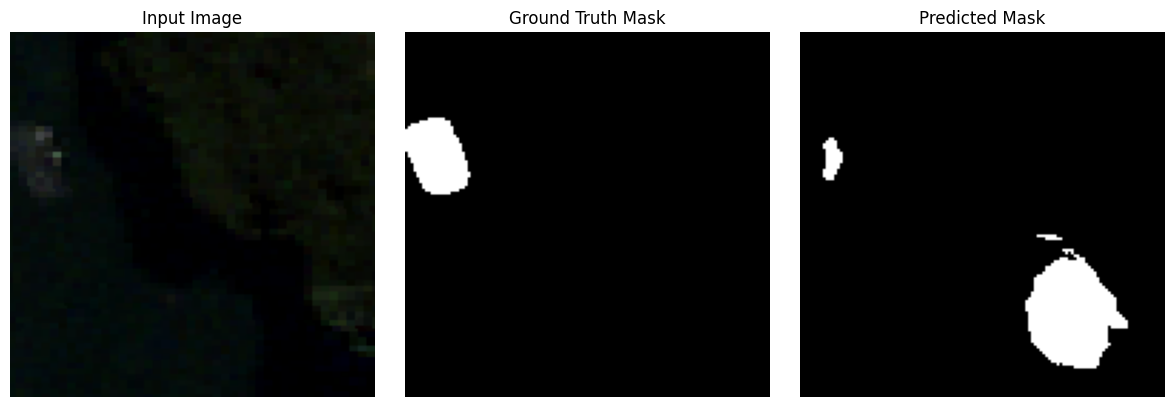

Epoch 50


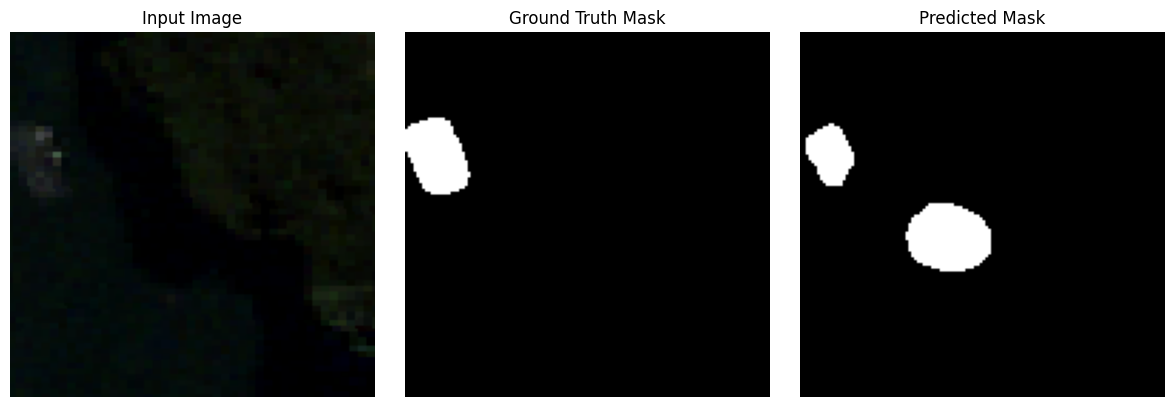

In [14]:
# Values for early stopping
best_val_iou = 0
patience = 15 # number of times where the performance is worst than the step before, to stop the training process
min_delta = 0.0002
counter = 0
saved_samples = [] #save image samples to check training performance

# Make sure the directory exists
os.makedirs(base_dir, exist_ok=True)

# Train the Model
# ----------------------------------------------------------------
# 6) Train + Validate Loop
# ----------------------------------------------------------------
for epoch in range(1, EPOCHS + 1):
    # Training
    model.train()
    train_loss = 0.0
    for im, mk in train_loader:
        im, mk = im.to(device), mk.to(device)
        opt.zero_grad()
        logits = model(im)
        loss   = bce(logits, mk) + soft_dice(logits, mk)
        loss.backward()
        opt.step()
        train_loss += loss.item() * im.size(0)

    train_loss /= len(train_ds)

    # Validation
    model.eval()
    val_loss, val_iou, val_dice = 0.0, 0.0, 0.0
    with torch.no_grad():
        for im, mk in val_loader:
            im, mk   = im.to(device), mk.to(device)
            logits   = model(im)
            loss     = bce(logits, mk) + soft_dice(logits, mk)
            val_loss += loss.item() * im.size(0)
            iou, dice = compute_iou_and_dice(logits, mk)
            val_iou  += iou * im.size(0)
            val_dice += dice * im.size(0)

    val_loss /= len(val_ds)
    val_iou  /= len(val_ds)
    val_dice /= len(val_ds)

    # Scheduler & Checkpoint
    scheduler.step() # Deprecated epoch parameter removed
    if val_iou > best_val_iou + min_delta:
        best_val_iou = val_iou

        # Save the model using a variable for the path
        save_path = os.path.join(base_dir, f"best_model_{channel}.pth")
        torch.save(model.state_dict(), save_path)

        counter = 0  # Reset counter if improvement
    else:
        counter += 1

    print(
        f"Epoch {epoch:02d}  "
        f"Train Loss {train_loss:.4f}  "
        f"Val Loss {val_loss:.4f}  "
        f"Val IoU {val_iou:.4f}  "
        f"Val Dice {val_dice:.4f} "
        f"Patience Counter {counter} "
    )

    # store image to print later
    if epoch % 10 == 0:
      im_sample, mk_sample = next(iter(val_loader))
      im_sample, mk_sample = im_sample.to(device), mk_sample.to(device)
      with torch.no_grad():
          pred_sample = model(im_sample)
      # Ensure mask and prediction samples are correctly shaped for visualization
      binary_pred_sample = (torch.sigmoid(pred_sample[0]) > 0.5).float()

      # Store CPU versions to save memory
      saved_samples.append({
          'image': im_sample[0].cpu(),
          'mask': mk_sample[0].cpu(), # Use corrected mask sample
          'prediction': binary_pred_sample.cpu(),
          'epoch': epoch
      })


    if counter >= patience:
        print(f"\n⛔ Early stopping triggered after {patience} epochs without improvement.")
        break


print(f"\nShowing stored predictions from training...\n")
for sample in saved_samples:
    print(f"Epoch {sample['epoch']}")
    show_image_mask_prediction(sample['image'], sample['mask'], sample['prediction'], num_input_channels=num_input_channels) # Pass num_input_channels

# Model Evaluation

---




Evaluating Model RGB...
Model RGB -> Loss: 0.1720, IoU: 0.8482, Dice: 0.9179


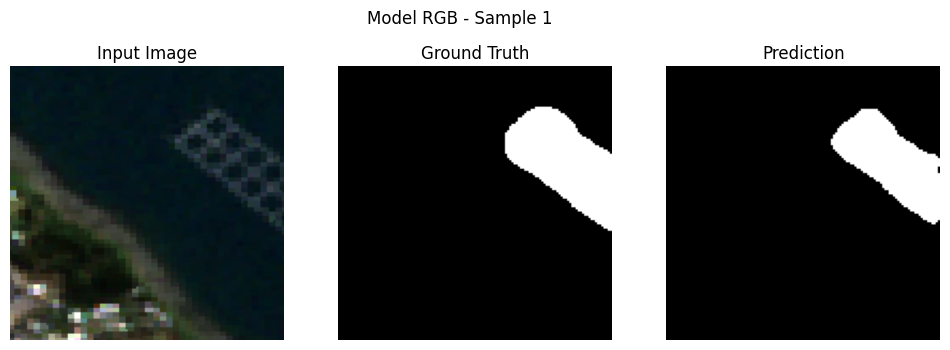

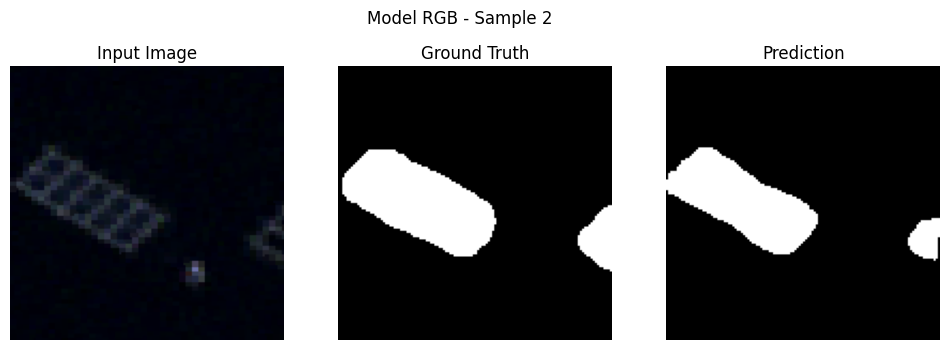

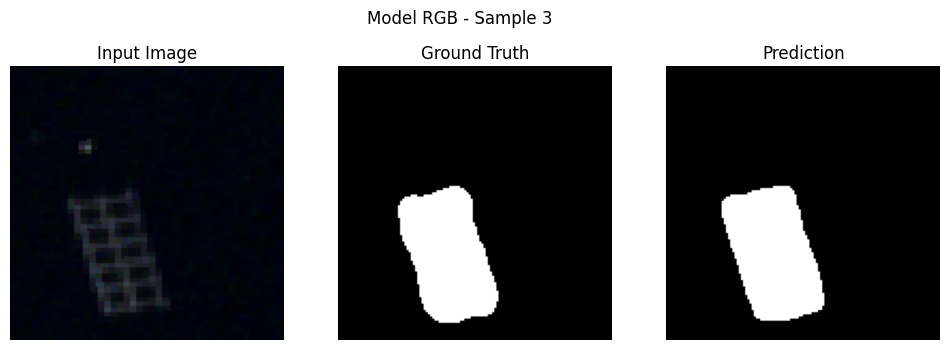


Summary:
Model RGB: Loss=0.1720, IoU=0.8482, Dice=0.9179
- Loss: Combination of BCEWithLogitsLoss and soft Dice loss, lower is better.
- IoU (Intersection over Union): Measures overlap between prediction and ground truth, 1 is perfect.
- Dice Coefficient: Measures similarity between prediction and ground truth masks, 1 is perfect.


In [16]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PATCH_SIZE = 128
# Define both 1-channel and 3-channel means and stds
IMG_MEAN_1_CHANNEL = (0.5,)
IMG_STD_1_CHANNEL  = (0.5,)
IMG_MEAN_3_CHANNEL = (0.485, 0.456, 0.406)
IMG_STD_3_CHANNEL  = (0.229, 0.224, 0.225)

# Dataset with albumentations transform
class SegmentationDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None, num_input_channels=3):
        self.imgs = img_paths
        self.msks = mask_paths
        self.transform = transform
        self.num_input_channels = num_input_channels

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        if self.num_input_channels == 1:
            img = np.load(self.imgs[idx]).astype(np.float32)
            img = np.expand_dims(img, axis=-1) # Add channel dimension H×W×1
        else: # 3 channels
            img = np.load(self.imgs[idx]).astype(np.float32)

        mask = np.array(Image.open(self.msks[idx]).convert("L"))
        mask = (mask >= PATCH_SIZE).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        if self.num_input_channels == 1:
             return img, mask.unsqueeze(0).float()                         # [1×H×W], [1×H×W]
        else:
             return img, mask.unsqueeze(0).float()                         # [3×H×W], [1×H×W]


# Compose the validation transform - Normalization will be applied based on num_input_channels later
val_transform = A.Compose([
    A.CropNonEmptyMaskIfExists(PATCH_SIZE, PATCH_SIZE, p=1.0),
    ToTensorV2()
])

def get_filtered_files(img_dir, mask_dir, patch_size=PATCH_SIZE):
    img_files = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith(".npy")])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith(".png")])

    filtered_imgs, filtered_masks = [], []
    for im, msk in zip(img_files, mask_files):
        mask_array = np.array(Image.open(msk).convert("L"))
        if (mask_array >= patch_size).sum() > 0:
            filtered_imgs.append(im)
            filtered_masks.append(msk)
    return filtered_imgs, filtered_masks

bce = nn.BCEWithLogitsLoss()

def soft_dice(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1,2,3))
    union = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()

def compute_iou_and_dice(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()
    iou = (intersection + 1e-6) / (union - intersection + 1e-6)
    dice = (2 * intersection + 1e-6) / (union + 1e-6)
    return iou.item(), dice.item()

def evaluate_model(model, dataloader, device, num_input_channels):
    model.eval()
    total_loss, total_iou, total_dice = 0, 0, 0
    all_imgs, all_masks, all_preds = [], [], []
    n_samples = len(dataloader.dataset)

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = bce(logits, masks) + soft_dice(logits, masks)

            total_loss += loss.item() * imgs.size(0)
            iou, dice = compute_iou_and_dice(logits, masks)
            total_iou += iou * imgs.size(0)
            total_dice += dice * imgs.size(0)

            preds = (torch.sigmoid(logits) > 0.5).float()
            all_imgs.append(imgs.cpu())
            all_masks.append(masks.cpu())
            all_preds.append(preds.cpu())

    avg_loss = total_loss / n_samples
    avg_iou = total_iou / n_samples
    avg_dice = total_dice / n_samples

    all_imgs = torch.cat(all_imgs)
    all_masks = torch.cat(all_masks)
    all_preds = torch.cat(all_preds)

    return avg_loss, avg_iou, avg_dice, all_imgs, all_masks, all_preds

def visualize_samples(images, masks, preds, num_samples=3, model_name=None, num_input_channels=3):
    if num_input_channels == 1:
        mean = torch.tensor(IMG_MEAN_1_CHANNEL).view(1, 1, 1)
        std = torch.tensor(IMG_STD_1_CHANNEL).view(1, 1, 1)
    else:
        mean = torch.tensor(IMG_MEAN_3_CHANNEL).view(3, 1, 1)
        std = torch.tensor(IMG_STD_3_CHANNEL).view(3, 1, 1)

    for i in range(min(num_samples, len(images))):
        img = images[i] * std + mean

        if num_input_channels == 1:
             img = img.squeeze(0).numpy() # Remove channel dim for grayscale display
             plt_img = img # Use grayscale image directly
        else:
            img = img.permute(1,2,0).numpy().clip(0,1)
            plt_img = img # Use RGB image

        mask = masks[i].squeeze().numpy()
        pred = preds[i].squeeze().numpy()

        fig, axs = plt.subplots(1,3, figsize=(12,4))
        if num_input_channels == 1:
            axs[0].imshow(plt_img, cmap='gray')
        else:
            axs[0].imshow(plt_img)

        axs[0].set_title("Input Image")
        axs[0].axis('off')

        axs[1].imshow(mask, cmap='gray')
        axs[1].set_title("Ground Truth")
        axs[1].axis('off')

        axs[2].imshow(pred, cmap='gray')
        axs[2].set_title("Prediction")
        axs[2].axis('off')

        if model_name:
            plt.suptitle(f"{model_name} - Sample {i+1}")
        plt.show()

def compare_models(models_info):
    """
    models_info: list of dicts with keys:
        - 'name': str, model name
        - 'model': PyTorch model instance
        - 'test_img_dir': str, path to test images
        - 'test_mask_dir': str, path to test masks
        - 'num_input_channels': int, number of channels for this model
    """
    results = []

    for info in models_info:
        print(f"\nEvaluating {info['name']}...")

        test_imgs, test_msks = get_filtered_files(info['test_img_dir'], info['test_mask_dir'])
        # Apply normalization based on num_input_channels before ToTensorV2
        if info['num_input_channels'] == 1:
            norm_transform = A.Normalize(mean=IMG_MEAN_1_CHANNEL, std=IMG_STD_1_CHANNEL)
        else:
            norm_transform = A.Normalize(mean=IMG_MEAN_3_CHANNEL, std=IMG_STD_3_CHANNEL)

        # Combine normalization and ToTensorV2
        current_val_transform = A.Compose([
            A.CropNonEmptyMaskIfExists(PATCH_SIZE, PATCH_SIZE, p=1.0),
            norm_transform,
            ToTensorV2()
        ])

        dataset = SegmentationDataset(test_imgs, test_msks, transform=current_val_transform, num_input_channels=info['num_input_channels'])
        dataloader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

        loss, iou, dice, imgs, masks, preds = evaluate_model(info['model'], dataloader, device, info['num_input_channels'])
        print(f"{info['name']} -> Loss: {loss:.4f}, IoU: {iou:.4f}, Dice: {dice:.4f}")

        visualize_samples(imgs, masks, preds, num_samples=3, model_name=info['name'], num_input_channels=info['num_input_channels'])

        results.append({
            "name": info['name'],
            "loss": loss,
            "iou": iou,
            "dice": dice,
        })
    return results


# Loading models
model_rgb = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
model_rgb.load_state_dict(torch.load(save_path, map_location=device))


models_info = [
    {
        "name": "Model RGB",
        "model": model_rgb,
        "test_img_dir": image_dir_test,
        "test_mask_dir": mask_dir_test,
        "num_input_channels": 3 # Specify channels for this model
    }
]

# If you want to run the comparison as originally intended, uncomment the compare_models call
results = compare_models(models_info)

print("\nSummary:")
for r in results:
    print(f"{r['name']}: Loss={r['loss']:.4f}, IoU={r['iou']:.4f}, Dice={r['dice']:.4f}")

print("- Loss: Combination of BCEWithLogitsLoss and soft Dice loss, lower is better.")
print("- IoU (Intersection over Union): Measures overlap between prediction and ground truth, 1 is perfect.")
print("- Dice Coefficient: Measures similarity between prediction and ground truth masks, 1 is perfect.")